# 03 — Exploratory Data Analysis
**Project:** Swiggy India Restaurant Analytics
**Dataset:** 10,083 restaurants across 6 metro cities — Hyderabad, Bangalore, Mumbai, Delhi, Kolkata, Chennai
**Goal:** Explore distributions, trends, and patterns. A business insight is written below every chart.

In [4]:
%pip install pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3.13 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == 'notebooks'
    else Path.cwd().resolve()
)

df = pd.read_csv(PROJECT_ROOT / 'data/processed/cleaned_dataset.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head() 

Shape: (10083, 12)
Columns: ['restaurant_name', 'cuisine', 'rating', 'offer_name', 'area', 'pure_veg', 'location', 'price_num', 'ratings_count', 'primary_cuisine', 'is_veg', 'num_offers']


,restaurant_name,cuisine,rating,offer_name,area,pure_veg,location,price_num,ratings_count,primary_cuisine,is_veg,num_offers
0,Burger King,"Burgers, American",4.2,DEAL OF DAY\n60% OFF UPTO ₹120\nUSE STEALDEALA...,Basavanagudi,No,Bangalore,350.0,10000.0,Burgers,0,3
1,Pizza Hut,Pizzas,3.9,"50% OFF UPTO ₹100\nUSE SWIGGYITABOVE ₹189, FLA...",Basavanagudi,No,Bangalore,350.0,5000.0,Pizzas,0,2
2,Theobroma,"Desserts, Bakery",4.6,"40% OFF UPTO ₹80\nUSE SPECIALSON SELECT ITEMS,...",Ashok Nagar,No,Bangalore,400.0,1000.0,Desserts,0,2
3,Starbucks Coffee,"Beverages, Cafe",4.2,"40% OFF UPTO ₹80\nUSE TRYNEWON SELECT ITEMS, F...",Basaveshwaranagar,No,Bangalore,400.0,100.0,Beverages,0,3
4,KFC,"Burgers, Biryani",4.2,No Offer,Basavanagudi,No,Bangalore,400.0,10000.0,Burgers,0,0


In [8]:
# Basic summary
print('Total restaurants:', len(df))
print('Rated restaurants:', df['rating'].notna().sum(), f"({df['rating'].notna().mean()*100:.1f}%)")
print('Avg rating:', df['rating'].mean().round(2))
print('Avg price for two: Rs', df['price_num'].mean().round(0))
print('Unique cuisines:', df['primary_cuisine'].nunique())
print()
df[['rating', 'price_num', 'ratings_count', 'num_offers']].describe().round(2)

Total restaurants: 10083
Rated restaurants: 7738 (76.7%)
Avg rating: 4.03
Avg price for two: Rs 313.0
Unique cuisines: 87



,rating,price_num,ratings_count,num_offers
count,7738.00,10058.00,7738.00,10083.00
mean,4.03,313.38,883.07,2.71
std,0.55,186.26,2289.09,1.59
min,1.50,20.00,2.00,0.00
25%,3.80,200.00,10.00,1.00
50%,4.10,296.50,100.00,2.00
75%,4.40,399.00,500.00,4.00
max,5.00,2000.00,10000.00,5.00


---
## Chart 1 — Rating Distribution

/var/folders/l5/3gqrzscs1vs1n0yr_szr0by80000gn/T/ipykernel_6261/328595601.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


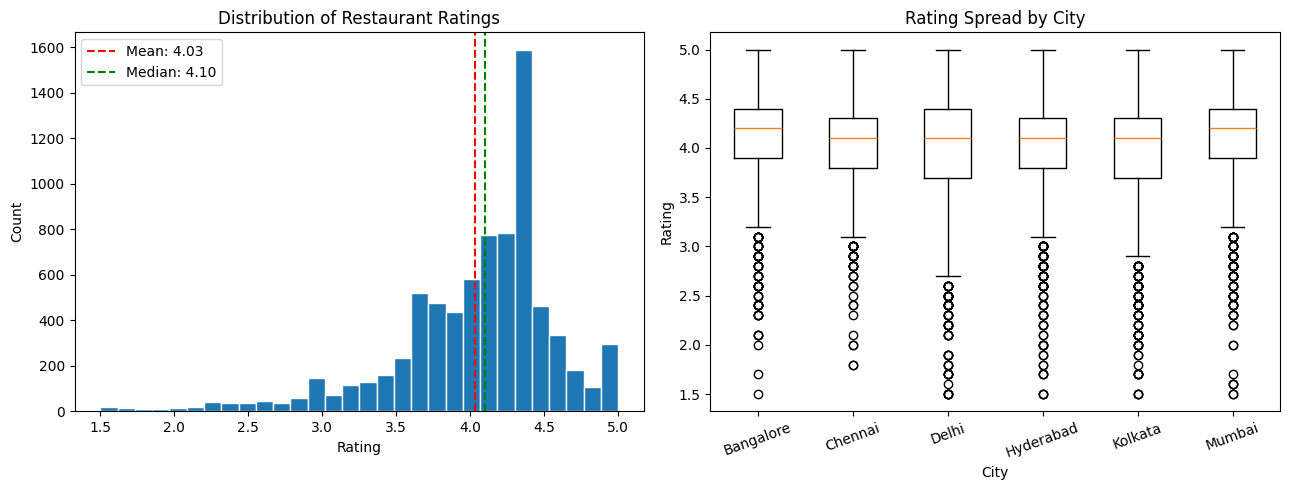

In [9]:
rated = df['rating'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(rated, bins=30, edgecolor='white')
axes[0].axvline(rated.mean(), color='red', linestyle='--', label=f'Mean: {rated.mean():.2f}')
axes[0].axvline(rated.median(), color='green', linestyle='--', label=f'Median: {rated.median():.2f}')
axes[0].set_title('Distribution of Restaurant Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(
    [df[df['location'] == city]['rating'].dropna()
     for city in df['location'].unique()],
    labels=df['location'].unique()
)
axes[1].set_title('Rating Spread by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Rating')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Business Insight:**
Ratings cluster tightly between 3.8 and 4.4 with a mean of 4.03. This narrow band means a restaurant that consistently scores 4.3+ stands out clearly. Bangalore and Mumbai show the highest median ratings while Delhi and Kolkata show more spread — suggesting higher quality inconsistency in those markets and more room for a well-run entrant to differentiate.

---
## Chart 2 — Average Rating by Cuisine (Top 10)

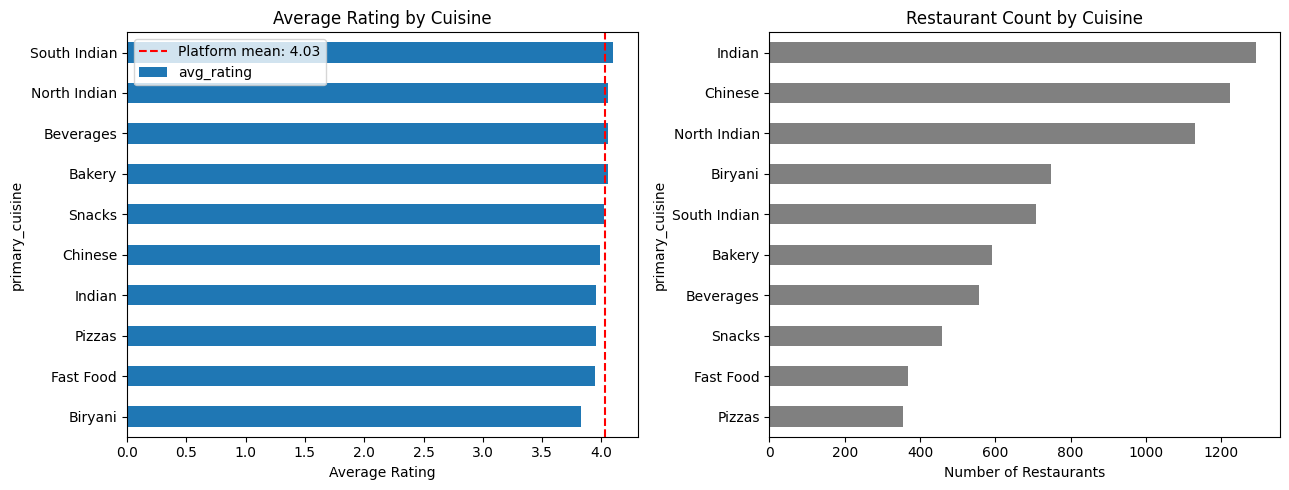

                 avg_rating  count
primary_cuisine                   
Biryani                3.83    749
Fast Food              3.95    368
Pizzas                 3.95    355
Indian                 3.95   1292
Chinese                3.99   1224
Snacks                 4.02    459
Bakery                 4.05    591
Beverages              4.05    557
North Indian           4.06   1130
South Indian           4.10    707


In [10]:
top10 = df['primary_cuisine'].value_counts().head(10).index

cuisine_stats = (
    df[df['primary_cuisine'].isin(top10)]
    .groupby('primary_cuisine')
    .agg(avg_rating=('rating', 'mean'), count=('restaurant_name', 'count'))
    .sort_values('avg_rating')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cuisine_stats['avg_rating'].plot(kind='barh', ax=axes[0])
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--',
                label=f'Platform mean: {df["rating"].mean():.2f}')
axes[0].set_title('Average Rating by Cuisine')
axes[0].set_xlabel('Average Rating')
axes[0].legend()

cuisine_stats['count'].sort_values().plot(kind='barh', ax=axes[1], color='grey')
axes[1].set_title('Restaurant Count by Cuisine')
axes[1].set_xlabel('Number of Restaurants')

plt.tight_layout()
plt.show()
print(cuisine_stats.round(2))

**Business Insight:**
South Indian (4.10) and North Indian (4.06) cuisines beat the platform average of 4.03. Biryani (3.83) ranks last despite being one of the most common cuisines — meaning the segment is large but quality is inconsistent. A new entrant in Biryani or Chinese (high count, average rating) has a clear opportunity to outperform the category average quickly with better execution.

---
## Chart 3 — Price vs Rating

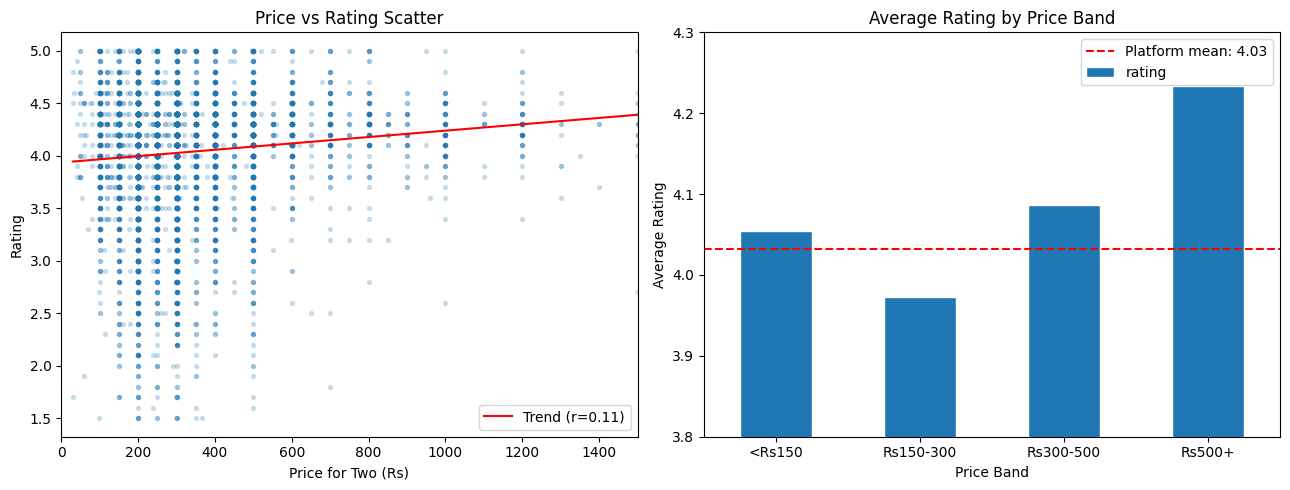

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

valid = df[['price_num', 'rating']].dropna()
axes[0].scatter(valid['price_num'], valid['rating'], alpha=0.2, s=8)
z = np.polyfit(valid['price_num'], valid['rating'], 1)
x_line = np.linspace(valid['price_num'].min(), valid['price_num'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=1.5, label='Trend (r=0.11)')
axes[0].set_title('Price vs Rating Scatter')
axes[0].set_xlabel('Price for Two (Rs)')
axes[0].set_ylabel('Rating')
axes[0].set_xlim(0, 1500)
axes[0].legend()

df['price_band'] = pd.cut(df['price_num'],
    bins=[0, 150, 300, 500, 99999],
    labels=['<Rs150', 'Rs150-300', 'Rs300-500', 'Rs500+'])
band_avg = df.groupby('price_band', observed=True)['rating'].mean()
band_avg.plot(kind='bar', ax=axes[1], edgecolor='white', rot=0)
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--',
                label=f'Platform mean: {df["rating"].mean():.2f}')
axes[1].set_title('Average Rating by Price Band')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.8, 4.3)
axes[1].legend()

plt.tight_layout()
plt.show()

**Business Insight:**
The correlation between price and rating is r=0.11 — very weak. Price explains only about 1% of rating variation. Mid-range (Rs150–300) and premium (Rs300–500) restaurants perform best. A new restaurant does not need to charge high prices to earn strong ratings — quality and consistency matter far more than premium positioning.

---
## Chart 4 — City-Level Comparison

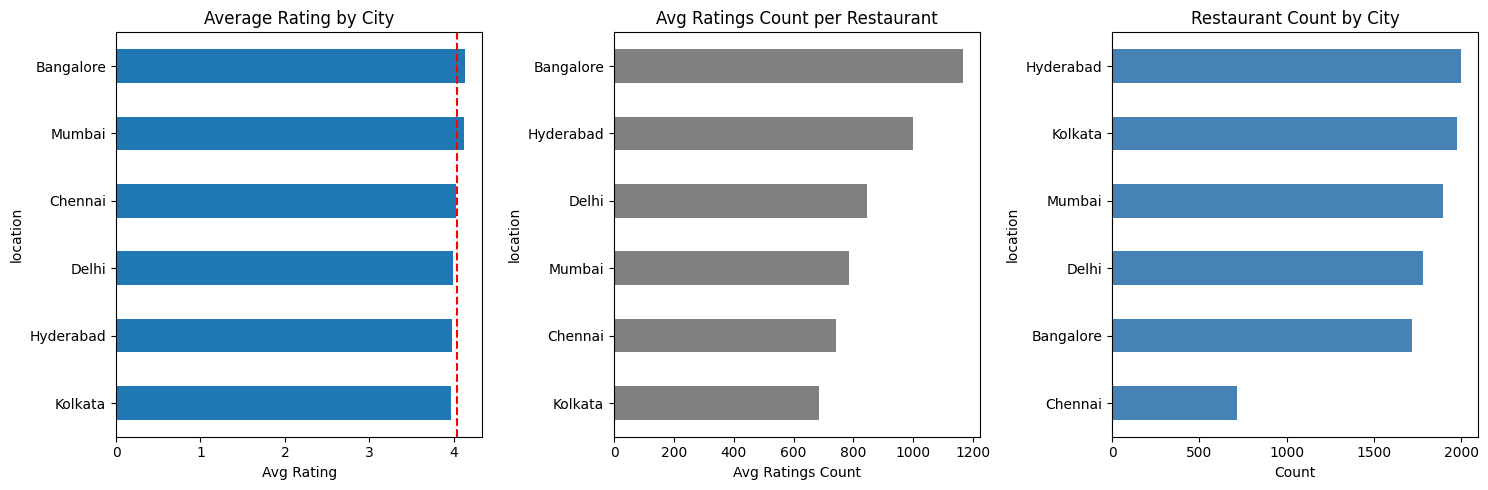

           avg_rating  avg_demand  count
location                                
Bangalore        4.13     1166.09   1720
Hyderabad        3.98      998.66   1998
Delhi            3.99      845.23   1783
Mumbai           4.12      783.91   1893
Chennai          4.02      743.31    715
Kolkata          3.96      684.32   1974


In [12]:
city_stats = df.groupby('location').agg(
    avg_rating=('rating', 'mean'),
    avg_demand=('ratings_count', 'mean'),
    count=('restaurant_name', 'count')
).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

city_stats['avg_rating'].sort_values().plot(kind='barh', ax=axes[0])
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--')
axes[0].set_title('Average Rating by City')
axes[0].set_xlabel('Avg Rating')

city_stats['avg_demand'].sort_values().plot(kind='barh', ax=axes[1], color='grey')
axes[1].set_title('Avg Ratings Count per Restaurant')
axes[1].set_xlabel('Avg Ratings Count')

city_stats['count'].sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Restaurant Count by City')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()
print(city_stats.sort_values('avg_demand', ascending=False))

**Business Insight:**
Bangalore leads in both average rating (4.13) and demand index (avg 1,166 ratings per restaurant) — it is the most competitive but also the most engaged market. Kolkata has high restaurant count but the lowest demand index (684), suggesting oversupply relative to active customer base. Chennai has the fewest restaurants (715) — potentially the easiest market for a quality new entrant to gain visibility.

---
## Chart 5 — Offers and Veg/Non-Veg Split

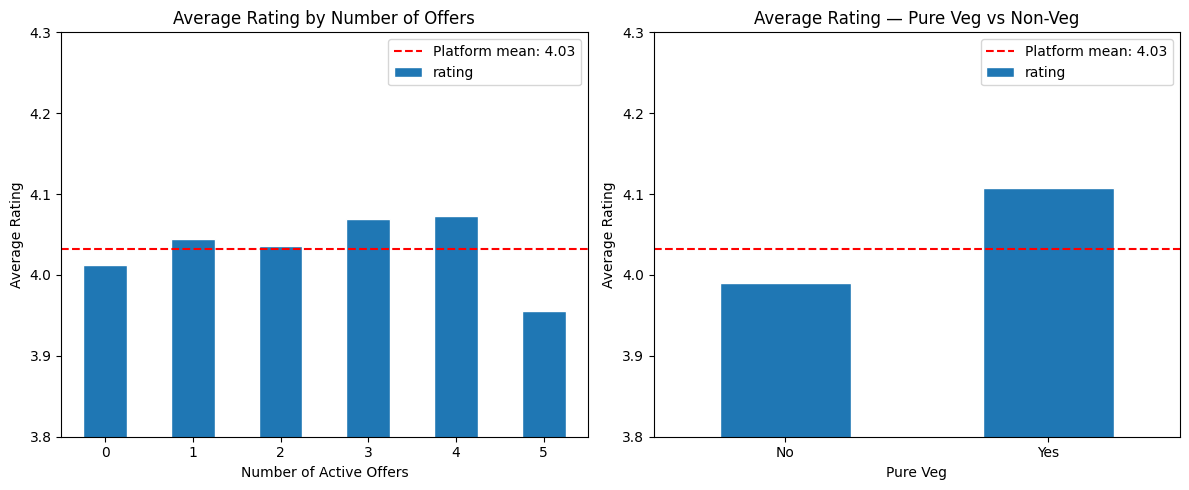

Veg mean: 4.108
Non-Veg mean: 3.99


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

offer_avg = df.groupby('num_offers')['rating'].mean()
offer_avg.plot(kind='bar', ax=axes[0], edgecolor='white', rot=0)
axes[0].axhline(df['rating'].mean(), color='red', linestyle='--',
                label=f'Platform mean: {df["rating"].mean():.2f}')
axes[0].set_title('Average Rating by Number of Offers')
axes[0].set_xlabel('Number of Active Offers')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3.8, 4.3)
axes[0].legend()

veg_avg = df.groupby('pure_veg')['rating'].mean()
veg_avg.plot(kind='bar', ax=axes[1], edgecolor='white', rot=0)
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--',
                label=f'Platform mean: {df["rating"].mean():.2f}')
axes[1].set_title('Average Rating — Pure Veg vs Non-Veg')
axes[1].set_xlabel('Pure Veg')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.8, 4.3)
axes[1].legend()

plt.tight_layout()
plt.show()
print('Veg mean:', df[df['pure_veg']=='Yes']['rating'].mean().round(3))
print('Non-Veg mean:', df[df['pure_veg']=='No']['rating'].mean().round(3))

**Business Insight:**
Number of active offers has no consistent effect on rating — confirmed later by t-test (p=0.77). Promotions drive order volume, not satisfaction scores. Pure veg restaurants score 0.12 points higher on average (4.11 vs 3.99), a statistically significant difference (p<0.0001). A veg-first menu positioning provides a measurable rating advantage on the Swiggy platform.

---
## Chart 6 — Cuisine × City Heatmap

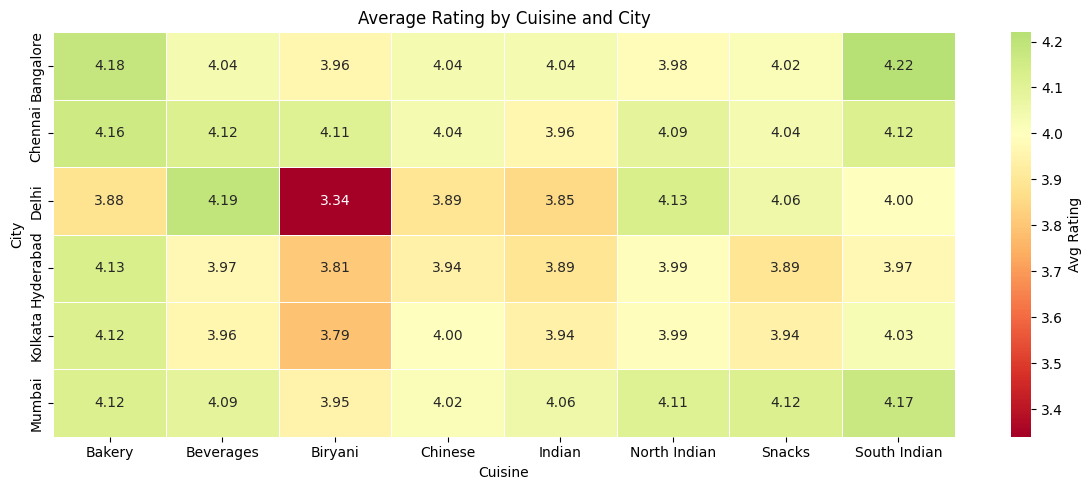

In [14]:
top8 = df['primary_cuisine'].value_counts().head(8).index
heatmap_data = (
    df[df['primary_cuisine'].isin(top8)]
    .groupby(['location', 'primary_cuisine'])['rating']
    .mean()
    .unstack()
    .round(2)
)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            center=4.0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg Rating'})
plt.title('Average Rating by Cuisine and City')
plt.xlabel('Cuisine')
plt.ylabel('City')
plt.tight_layout()
plt.show()

**Business Insight:**
The heatmap shows which cuisine-city combinations perform well (green) and which underperform (red). Blank cells indicate a cuisine that barely exists in that city — a direct market gap. For example, a cuisine that scores consistently green across other cities but is absent or red in a specific metro signals an undersupply opportunity where a quality entrant can capture share quickly.